# 데이터 전처리 - 01

## 환경 설정

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from lab_core.styles.viz import setup_global
from lab_core.util.path import raw_data_dir, ext_data_dir
from lab_core.hyj.data.clieaning import rename_columns
from lab_core.hyj.data.data_skim import skim_schema
from lab_core.hyj.data.data_compare import compare_schema
from lab_core.hyj.data.data_beautify import GroupDict, beautify_columns

setup_global()


## 데이터셋 로드 및 관찰
- 대회용 train, test 셋을 우선 로드
- 지리정보 취합을 위한 서울 아파트 정보 k_apt 셋 로드
- train 셋의 target 변수 분리 (x_train, y_train)

In [2]:
train_path = raw_data_dir("train.csv")
test_path = raw_data_dir("test.csv")
k_apt_path = ext_data_dir("k-apt.csv")

train = pd.read_csv(train_path)
x_train = train.drop("target", axis=1)
y_train = train["target"]
test = pd.read_csv(test_path)
k_apt = pd.read_csv(k_apt_path)

imp_features = []  # 주요 변수라 생각되는 것들을 수집.

/tmp/ipykernel_810390/1850792737.py:5: DtypeWarning: Columns (16,17,36) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(train_path)


- x_train 데이터를 우선 가볍게 훑어 본다.

In [3]:
seed = 222
df = x_train
t_skimmed = skim_schema(df, random_state=seed)
display(t_skimmed)

,col,dtype,kind,n_rows,na_cnt,na_rate,nunique,samples_non_na,top3,bottom3,vc_sampled,vc_sample_n
0,k-135㎡초과,float64,numeric,1118822,1118495,0.999708,1,"70.0, 70.0, 70.0",70.0:327,70.0:327,False,327
1,해제사유발생일,float64,numeric,1118822,1112839,0.994652,1025,"20230515.0, 20230614.0, 20230712.0",20220211.0:151; 20200727.0:43; 20200714.0:40,20221125.0:1; 20220804.0:1; 20220328.0:1,False,5983
2,k-등록일자,object,categorical,1118822,1107832,0.990177,126,"'2022-11-09 20:10:43.0', '2022-11-09 20:10:43....",'2017-02-01 10:49:21.0':1857; '2017-02-10 12:2...,'2020-12-31 22:40:22.0':1; '2022-01-05 18:02:2...,False,10990
3,단지소개기존clob,float64,numeric,1118822,1050240,0.938702,94,"2888.0, 2888.0, 2888.0",4.0:6978; 1474.0:732; 638.0:679,1417.0:20; 1.0:23; 2039.0:27,True,20000
4,k-홈페이지,object,categorical,1118822,1005647,0.898844,221,"'test', 'test', 'test'",'없음':658; 'www.jsls.co.kr':548; 'www.oftapt.co...,'cafe.naver.com':1; 'http://sgpark.xisnd.co.kr...,True,20000
5,고용보험관리번호,object,categorical,1118822,913304,0.816309,526,"'21380015910', '21380015910', '21380015910'",'909-01-23103-1':290; '21380014370':269; '907-...,'10481985950':1; '91919837281':1; '91921165861':2,True,20000
6,세대전기계약방법,object,categorical,1118822,878747,0.785422,2,"'단일계약', '단일계약', '단일계약'",'종합계약':10258; '단일계약':9742,'단일계약':9742; '종합계약':10258,True,20000
7,k-팩스번호,object,categorical,1118822,872742,0.780054,1364,"'025776673', '025776673', '025776673'",'02-572-3212':227; '025613140':209; 25334075.0...,'0220601688':1; '025886065':1; '024491490':1,True,20000
8,k-시행사,object,categorical,1118822,871254,0.778724,555,"'모름', '모름', '모름'",'SH공사':1059; '대한주택공사':630; '도시개발공사':357,'(주)수경하우징':1; '국제자산신탁(주)':1; '사당2주택 재건축정비사업조합':1,True,20000
9,청소비관리형태,object,categorical,1118822,871178,0.778656,4,"'직영', '직영', '직영'",'위탁':18177; '직영':1216; '위탁+직영':337,'기타':270; '위탁+직영':337; '직영':1216,True,20000


`skim_schema` 함수는 데이터셋의 변수 특성을 가볍게 훑기 좋도록 요약된 정보를 제공.
- 데이터가 너무 많으면 샘플링하여 확인.
- 결측치 정보와 함께, 정상 값들의 유형 파악을 위한 샘플 데이터 값 제공.

## 각 변수별 전처리

#### 결측치로 취급되는 값을 가지고 있는 변수들 전처리
- `등기신청일자` : 공백 문자를 결측치로 취급

In [4]:
df["등기신청일자"].value_counts().head(3)

등기신청일자
            1103907
20230630        585
20230428        394
Name: count, dtype: int64

- `거래유형` : '-'을 결측치로 취급

In [5]:
df["거래유형"].value_counts().head(3)

거래유형
-       1086451
중개거래      29271
직거래        3100
Name: count, dtype: int64

- `중개사소재지` : '-'을 결측치로 취급

In [6]:
df["중개사소재지"].value_counts().head(3)

중개사소재지
-         1089581
서울 강남구       2000
서울 송파구       1995
Name: count, dtype: int64

위 컬럼들의 결측치에 해당하는 값들을 `np.nan`으로 대체.

In [7]:
df['등기신청일자'] = df['등기신청일자'].replace(' ', np.nan)
df['거래유형'] = df['거래유형'].replace('-', np.nan)
df['중개사소재지'] = df['중개사소재지'].replace('-', np.nan)

유사 결측치 처리를 끝낸 후 다시 데이터셋을 재확인.

In [8]:
t_skimmed = skim_schema(df, random_state=seed)
display(t_skimmed)

,col,dtype,kind,n_rows,na_cnt,na_rate,nunique,samples_non_na,top3,bottom3,vc_sampled,vc_sample_n
0,k-135㎡초과,float64,numeric,1118822,1118495,0.999708,1,"70.0, 70.0, 70.0",70.0:327,70.0:327,False,327
1,해제사유발생일,float64,numeric,1118822,1112839,0.994652,1025,"20230515.0, 20230614.0, 20230712.0",20220211.0:151; 20200727.0:43; 20200714.0:40,20221125.0:1; 20220804.0:1; 20220328.0:1,False,5983
2,k-등록일자,object,categorical,1118822,1107832,0.990177,126,"'2022-11-09 20:10:43.0', '2022-11-09 20:10:43....",'2017-02-01 10:49:21.0':1857; '2017-02-10 12:2...,'2020-12-31 22:40:22.0':1; '2022-01-05 18:02:2...,False,10990
3,등기신청일자,object,categorical,1118822,1103907,0.986669,181,"'20230920', '20230330', '20230420'",'20230630':585; '20230428':394; '20230831':391,'20230104':1; '20230102':1; '20230109':1,False,14915
4,중개사소재지,object,categorical,1118822,1089581,0.973864,642,"'서울 강남구, 서울 송파구', '서울 강남구', '서울 강남구'",'서울 강남구':1383; '서울 노원구':1360; '서울 송파구':1355,"'부산 해운대구, 서울 강남구, 서울 용산구':1; '경기 수원영통구, 서울 송파구...",True,20000
5,거래유형,object,categorical,1118822,1086451,0.971067,2,"'중개거래', '중개거래', '중개거래'",'중개거래':18044; '직거래':1956,'직거래':1956; '중개거래':18044,True,20000
6,단지소개기존clob,float64,numeric,1118822,1050240,0.938702,94,"2888.0, 2888.0, 2888.0",4.0:6978; 1474.0:732; 638.0:679,1417.0:20; 1.0:23; 2039.0:27,True,20000
7,k-홈페이지,object,categorical,1118822,1005647,0.898844,221,"'test', 'test', 'test'",'없음':658; 'www.jsls.co.kr':548; 'www.oftapt.co...,'cafe.naver.com':1; 'http://sgpark.xisnd.co.kr...,True,20000
8,고용보험관리번호,object,categorical,1118822,913304,0.816309,526,"'21380015910', '21380015910', '21380015910'",'909-01-23103-1':290; '21380014370':269; '907-...,'10481985950':1; '91919837281':1; '91921165861':2,True,20000
9,세대전기계약방법,object,categorical,1118822,878747,0.785422,2,"'단일계약', '단일계약', '단일계약'",'종합계약':10258; '단일계약':9742,'단일계약':9742; '종합계약':10258,True,20000


#### 실제 무의미한 값들 분석 및 전처리

- `중개사소재지`
  이는 거래를 중개한 주체의 위치 정보로,
  아파트 단지의 물리적·행정적·입지적 특성과 직접적인 관련이 없으며
  중개사 선택은 거래 시점의 개인적·우연적 요인에 좌우된다.
  또한 결측률이 높고 동일 단지 내에서도 값의 일관성이 없어
  실거래가 예측에 유의미한 정보를 제공하지 못하므로
  모델 입력 컬럼에서 제거한다.

- `k-등록일자`, `k-수정일자`
  이 데이터셋의 추가/변경이력에 해당하며, 
  데이터 관리상태와 실거래가는 상관관계가 없다.

- `단지소개기존clob`
  이 데이터셋을 관리하던 예전 Legacy 시스템과 호환되는 값으로 추정되며, 아파트 실거래가와 상관관계가 없다.

- `고용보험관리번호`, `관리비 업로드`
  이 데이터셋 관리 주체의 행정상 필요한 값으로 추정되며,
  아파트 실거래가와 상관관계가 없다.

- `k-전화번호`, `k-팩스번호`, `k-홈페이지`
  아파트 관리 사무소와 관련된 정보로 판단되며,
  관리 사무소가 운영되는 아파트라는 간접 정보이지만,
  실거래가와 상관관계는 없다고 본다.
  홈페이지 유무는 상대적으로 가치가 있을 수도 있지만,
  결측률이 높고 무의미한 값들도 많아서 적합하지 않다.

- `번지`, `본번`, `부번`
  본래 아파트 좌표 값 결측치를 채우기 위한 보조 정보로 활용하려 했으나
  도로명 주소 정보만으로 충분히 좌표 값을 확인 가능하다고 판단했다.
  아파트 지리 정보는 `좌표값`과 `구`, `동` 정도로 충분하다.

  
> 참고: `중개사소재지`를 제외한 일부 컬럼은 K-APT 원천 데이터에도 존재하므로,
> 좌표 보정·단지 매칭 등 데이터 정합성 검증 단계까지는 유지하되,
> 최종 모델 입력 단계에서는 제거 대상으로 분류한다.

In [9]:
# 중개사소재지 컬럼 제거
df = df.drop("중개사소재지", axis=1)
df = df.drop("번지", axis=1)
df = df.drop("본번", axis=1)
df = df.drop("부번", axis=1)

#### `시군구` 전처리

`시군구` 데이터 샘플을 보면, `서울특별시 ㅇㅇ구 ㅇㅇ동`의 형태로 구성되어 있음을 알 수 있다.
컬럼명과는 다르게 행정동 정보가 포함되어 있으므로 분리할 필요가 있다.
또, 이 대회의 목적은 `서울시` 아파트의 실거래가를 예측하는 것이므로, 최대한 유의미한 정보만 남긴다는 차원에서 `서울특별시` 문구도 제거한다.

In [10]:
s = df["시군구"].astype(str)

df["구"] = s.str.extract(r"(\S+구)", expand=False)
df["동"] = s.str.extract(r"(\S+동)", expand=False)

df = df.drop(columns=["시군구"])


#### `계약일자` 전처리

대회의 목적은 특정 `아파트 거래의 실거래가(거래금액)` 를 예측하는 것이다.
계약 이벤트가 시간에 따라 발생하므로 `시간 정보(계약일자) 가 중요한 설명 변수`가 되며,
검증/학습 분할에서도 `시간 누수(time leakage) 를 방지`하기 위해 `시간 축을 명확히` 다룰 필요가 있다.

원본의 `계약년월`, `계약일`은 숫자 형태로 저장되어 있어 `날짜형(datetime)`으로 자동 인식되지 않으므로,
`계약일자(datetime) 파생 변수`를 생성해 `시간 정보를 명확하게 표현`한다.

1) `계약년월`을 `계약년`과 `계약월`로 분리합니다.

In [11]:
ym = df["계약년월"].astype(str)

# 계약년월의 모든 값들이 통일된 양식을 가지고 있는지 판단합니다.
if not ym.str.fullmatch(r"\d{6}").all():
    raise ValueError("계약년월 컬럼에 YYYYMM 형식이 아닌 값이 존재합니다.")

df["계약년"] = ym.str.slice(0, 4).astype(int)
df["계약월"] = ym.str.slice(4, 6).astype(int)

# 알려진 데이터 범위인 2007-01-01 부터 2023-06-30 까지에 속하는지 확인

if not df["계약년"].between(2007, 2023).all():
    raise ValueError("계약년 컬럼에 2007~2023 범위를 벗어난 값이 존재합니다.")

if not df["계약월"].between(1, 12).all():
    raise ValueError("계약월 컬럼에 1~12 범위를 벗어난 값이 존재합니다.")

if not df["계약일"].between(1, 31).all():
    raise ValueError("계약일 컬럼에 1~31 범위를 벗어난 값이 존재합니다.")

# 데이터 범위까지 검증되었다면, 계약년월 컬럼은 제거합니다.
df = df.drop("계약년월", axis=1)

df[["계약년", "계약월", "계약일"]].head(10)

,계약년,계약월,계약일
0,2017,12,8
1,2017,12,22
2,2017,12,28
3,2018,1,3
4,2018,1,8
5,2018,1,11
6,2018,3,19
7,2018,4,5
8,2018,6,28
9,2018,7,9


2) `계약년` + `계약월` + `계약일`을 조합한 `계약년월` 변수를 추가합니다.

In [12]:
# 앞서 분리한 계약년, 계약월, 계약일 컬러을 합쳐서 dtype: datetime64[ns]인 계약일자 파생 변수를 생성.

df["계약일자"] = pd.to_datetime(
    df["계약년"].astype(str)
    + "-"
    + df["계약월"].astype(str).str.zfill(2)
    + "-"
    + df["계약일"].astype(str).str.zfill(2),
    format="%Y-%m-%d",
    errors="raise",  # 오류 체크 필요.
)

print(df["계약일자"].dtype)
df["계약일자"].head(10)

datetime64[ns]


0   2017-12-08
1   2017-12-22
2   2017-12-28
3   2018-01-03
4   2018-01-08
5   2018-01-11
6   2018-03-19
7   2018-04-05
8   2018-06-28
9   2018-07-09
Name: 계약일자, dtype: datetime64[ns]

위와 같이 `계약일자`가 dtype이 `datetime64[ns]`로 잘 인식됨을 알 수 있습니다.

#### 2.1.2. `해제사유발생일`에 관한 고찰

##### 해제사유발생일이란?
부동산 거래가 정식으로 성사되지 않고 해제·무효·취소되었음이 확정된 날짜를 의미한다.

그러므로 결측치가 많을 수 밖에 없고, 결측치는 유의미하게 해석되어야 한다.

데이터에 `is_canceled` 값을 추가하고,
`해제사유발생일`이 존재하는 행은 1, 나머지 결측행은 0으로 표기하고,
`해제사유발생일` 컬럼을 제거한다.

`is_canceled` == 1로 표기된 행들은, 추후 모델 학습 단계에서는 제거할 것들이므로,
데이터 전처리 과정 동안에만 참고용으로 남겨두고,
모델 학습 단계 전에 `is_canceled` == 1인 행들과 `is_canceled` 컬럼까지 모두 제거한다.

In [13]:
df["is_canceled"] = df["해제사유발생일"].notna().astype(int)
display(df["is_canceled"].value_counts())

is_canceled
0    1112839
1       5983
Name: count, dtype: int64

In [14]:
df = df.drop("해제사유발생일", axis=1)
print("해제사유발생일" in x_train.columns)

True


#### 2.1.3. `건축년도`에 관한 고찰

`건축년도`는 거래 당시의 건물 노후화 상태를 판단할 수 있는 중요한 지표이다.

그러므로 `계약년` - `건축년도` = `건물나이` 라는 파생 변수를 생성하고,
모델 학습에 중요한 변수로 기록해 둔다.
`건축년도` 는 데이터 전처리 과정에서 다른 컬럼과 조합하여,
새로운 파생 변수를 만들어 낼 가능성이 있으므로 유지하고,
모델 학습 단계 전에 제거하도록 한다.

`건축년도`는 결측치가 없는 변수지만, 모든 값들이 유효한지 검증할 필요가 있다.

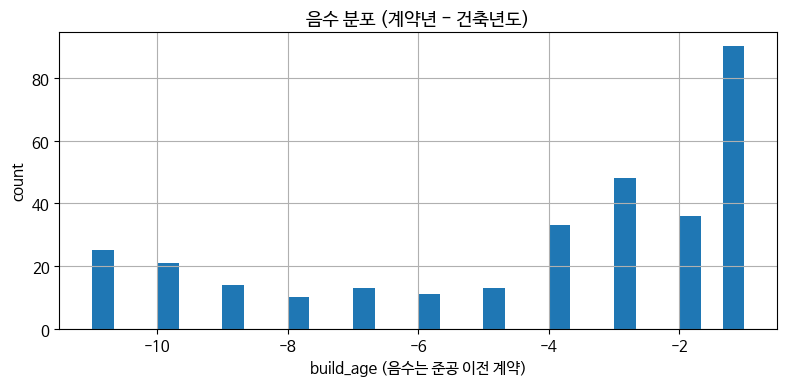

In [15]:
build_y = df["건축년도"].astype(str).str.strip()

# 건축년도의 모든 값들이 통일된 양식을 가지고 있는지 판단합니다.
if not build_y.str.fullmatch(r"\d{4}").all():
    raise ValueError("건축년도 컬럼에 YYYY 형식이 아닌 값이 존재합니다.")

df["건축년도"] = build_y.astype(int)

# 건축년도의 범위 체크 (1937년 준공된 충정아파트 기준)
if not df["건축년도"].between(1937, 2023).all():
    raise ValueError("건축년도 컬럼에 1937~2023 범위를 벗어난 값이 존재합니다.")

# 건물나이 계산
build_age = df["계약년"] - df["건축년도"]

# 건물나이가 음수 분포 시각화
mk_neg = build_age < 0
df_neg = df.loc[mk_neg].copy()  # 시각화용 임시 df
df_neg["build_age"] = build_age.loc[mk_neg]

plt.figure(figsize=(8, 4))
df_neg["build_age"].hist(bins=30)
plt.title("음수 분포 (계약년 - 건축년도)")
plt.xlabel("build_age (음수는 준공 이전 계약)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [16]:
# 1) 계약이 1~2년 선행되는 것은 정상 범주로 본다.
# 2) 계약이 3~4년 선행되는 것은 특수한 실제 사례로 본다.
# 3) 계약이 5년 이상 선행되는 것은 데이터 오류로 보고 드랍한다.

# 비정상 계약 제거 (이상치 제거)
df = df[build_age >= -4].copy()

# 이상치 제거 후 다시 계산
build_age = df["계약년"] - df["건축년도"]

# 건물나이 파생변수 생성 (연속형, 0 이상)
df["건물나이"] = build_age.clip(lower=0).astype(int)

# 건축지연도 파생 변수 생성 (범주형, 0~4)
delay = (-build_age).clip(lower=0).astype(int)
df["건축지연도"] = delay.astype("category")

# 건축지연도 변수 정보
# df["건축지연도"].cat.categories
df.loc[df["건축지연도"].cat.codes > 2].head(10)

,아파트명,전용면적(㎡),계약일,층,건축년도,도로명,등기신청일자,거래유형,"k-단지분류(아파트,주상복합등등)",k-전화번호,...,좌표Y,단지신청일,구,동,계약년,계약월,계약일자,is_canceled,건물나이,건축지연도
349563,마포자이더센트리지,84.987,25,2,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2019,11,2019-11-25,0,0,3
419716,마포자이더센트리지,34.790,18,4,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4
419717,마포자이더센트리지,34.790,18,7,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4
419718,마포자이더센트리지,34.790,18,5,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4
419719,마포자이더센트리지,34.790,18,3,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4
419720,마포자이더센트리지,34.790,18,8,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4
419721,마포자이더센트리지,34.790,18,11,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4
419722,마포자이더센트리지,34.790,18,12,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4
419723,마포자이더센트리지,34.790,18,13,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4
419724,마포자이더센트리지,34.790,18,14,2022,숭문길 98,NaN,NaN,NaN,NaN,...,NaN,NaN,마포구,염리동,2018,12,2018-12-18,0,0,4


In [17]:
t_skimmed = skim_schema(df, random_state=seed)
display(t_skimmed)

,col,dtype,kind,n_rows,na_cnt,na_rate,nunique,samples_non_na,top3,bottom3,vc_sampled,vc_sample_n
0,k-135㎡초과,float64,numeric,1118715,1118388,0.999708,1,"70.0, 70.0, 70.0",70.0:327,70.0:327,False,327
1,k-등록일자,object,categorical,1118715,1107725,0.990176,126,"'2022-11-09 20:10:43.0', '2022-11-09 20:10:43....",'2017-02-01 10:49:21.0':1857; '2017-02-10 12:2...,'2020-12-31 22:40:22.0':1; '2022-01-05 18:02:2...,False,10990
2,등기신청일자,object,categorical,1118715,1103800,0.986668,181,"'20230920', '20230330', '20230420'",'20230630':585; '20230428':394; '20230831':391,'20230104':1; '20230102':1; '20230109':1,False,14915
3,거래유형,object,categorical,1118715,1086344,0.971064,2,"'중개거래', '중개거래', '중개거래'",'중개거래':18044; '직거래':1956,'직거래':1956; '중개거래':18044,True,20000
4,단지소개기존clob,float64,numeric,1118715,1050133,0.938696,94,"2888.0, 2888.0, 2888.0",4.0:6978; 1474.0:732; 638.0:679,1417.0:20; 1.0:23; 2039.0:27,True,20000
5,k-홈페이지,object,categorical,1118715,1005540,0.898835,221,"'test', 'test', 'test'",'없음':658; 'www.jsls.co.kr':548; 'www.oftapt.co...,'cafe.naver.com':1; 'http://sgpark.xisnd.co.kr...,True,20000
6,고용보험관리번호,object,categorical,1118715,913197,0.816291,526,"'21380015910', '21380015910', '21380015910'",'909-01-23103-1':290; '21380014370':269; '907-...,'10481985950':1; '91919837281':1; '91921165861':2,True,20000
7,세대전기계약방법,object,categorical,1118715,878640,0.785401,2,"'단일계약', '단일계약', '단일계약'",'종합계약':10258; '단일계약':9742,'단일계약':9742; '종합계약':10258,True,20000
8,k-팩스번호,object,categorical,1118715,872635,0.780033,1364,"'025776673', '025776673', '025776673'",'02-572-3212':227; '025613140':209; 25334075.0...,'0220601688':1; '025886065':1; '024491490':1,True,20000
9,k-시행사,object,categorical,1118715,871147,0.778703,555,"'모름', '모름', '모름'",'SH공사':1059; '대한주택공사':630; '도시개발공사':357,'(주)수경하우징':1; '국제자산신탁(주)':1; '사당2주택 재건축정비사업조합':1,True,20000


#### train과 k-apt 데이터셋 비교
- 두 데이터 셋에서 겹치는 데이터를 찾아서 `위경도` 데이터를 합칠 수 있게 준비.

In [18]:
compared = compare_schema(left=x_train, right=k_apt, left_name="train", right_name="apt")
display(compared)

,col,in_left,in_right,presence,train_dtype,train_n_rows,train_na_cnt,train_na_rate,train_non_na_cnt,train_nunique,...,apt_dtype,apt_n_rows,apt_na_cnt,apt_na_rate,apt_non_na_cnt,apt_nunique,apt_top_values,apt_samples,dtype_mismatch,na_rate_diff
0,Unnamed: 0,False,True,only_apt,None,NaN,NaN,NaN,NaN,NaN,...,int64,2852.0,0.0,0.000000,2852.0,2852.0,0:1; 1916:1; 1896:1,"0, 1, 2",False,NaN
1,k-아파트명,False,True,only_apt,None,NaN,NaN,NaN,NaN,NaN,...,object,2852.0,0.0,0.000000,2852.0,2842.0,'신동아아파트':3; '우리유앤미':2; '경남아너스빌':2,"'우리유앤미', '송파파인타운13단지', '오금현대백조(임대)'",False,NaN
2,k-아파트코드,False,True,only_apt,None,NaN,NaN,NaN,NaN,NaN,...,object,2852.0,0.0,0.000000,2852.0,2852.0,'A15679103':1; 'A13579505':1; 'A13552001':1,"'A15679103', 'A13876112', 'A13873701'",False,NaN
3,kapt도로명주소,False,True,only_apt,None,NaN,NaN,NaN,NaN,NaN,...,object,2852.0,64.0,0.022440,2788.0,2707.0,'서울특별시 성북구 종암로23길 35':3; '서울특별시 강남구 개포로 310':2...,"'서울특별시 동작구 서달로 83', '서울특별시 송파구 송파대로8길 10', '서울...",False,NaN
4,거래유형,True,False,only_train,object,1118822.0,1086451.0,0.971067,32371.0,2.0,...,None,NaN,NaN,NaN,NaN,NaN,None,None,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,세대전기계약방법,True,True,both,object,1118822.0,878747.0,0.785422,240075.0,2.0,...,object,2852.0,200.0,0.070126,2652.0,2.0,'종합계약':1351; '단일계약':1301,"'단일계약', '단일계약', '단일계약'",False,0.715295
59,좌표X,True,True,both,float64,1118822.0,869670.0,0.777309,249152.0,741.0,...,float64,2852.0,40.0,0.014025,2812.0,2765.0,126.9764363:5; 127.0144609:3; 126.8195884:2,"126.9596386, 127.1291789, 127.1287745",False,0.763283
60,좌표Y,True,True,both,float64,1118822.0,869670.0,0.777309,249152.0,741.0,...,float64,2852.0,40.0,0.014025,2812.0,2766.0,37.4886826:5; 37.5464825:3; 37.4785869:2,"37.5006676, 37.4768967, 37.5089058",False,0.763283
61,주차대수,True,True,both,float64,1118822.0,869714.0,0.777348,249108.0,526.0,...,float64,2852.0,39.0,0.013675,2813.0,1113.0,0.0:223; 200.0:14; 1.0:14,"223.0, 225.0, 60.0",False,0.763673


분석 결과를 보기 좋게 재구성합니다.

In [19]:
COLS_VIEW: list[GroupDict] = [
    {
        "name": "컬럼명",
        "cols": [ "col" ]
    },
    {
        "name": "어느 데이터셋",
        "desc": "both, only_train, only_apt",
        "cols": [ "presence" ]
    },
    {
        "name": "무슨 타입",
        "desc": "두 컬럼이 같은 타입을 가지나?",
        "cols": [ "dtype_mismatch", "train_dtype", "apt_dtype" ]
    },
    {
        "name": "행의 수",
        "cols": [ "train_n_rows", "apt_n_rows" ]
    },
    {
        "name": "데이터 샘플",
        "desc": "두 컬럼이 유사한 데이터를 가지나?",
        "cols": [ "train_samples", "apt_samples" ]
    }
]

df_view = beautify_columns(compared, COLS_VIEW)
display(df_view)

,col,presence,dtype_mismatch,train_dtype,apt_dtype,train_n_rows,apt_n_rows,train_samples,apt_samples
0,Unnamed: 0,only_apt,False,None,int64,NaN,2852.0,None,"0, 1, 2"
1,k-아파트명,only_apt,False,None,object,NaN,2852.0,None,"'우리유앤미', '송파파인타운13단지', '오금현대백조(임대)'"
2,k-아파트코드,only_apt,False,None,object,NaN,2852.0,None,"'A15679103', 'A13876112', 'A13873701'"
3,kapt도로명주소,only_apt,False,None,object,NaN,2852.0,None,"'서울특별시 동작구 서달로 83', '서울특별시 송파구 송파대로8길 10', '서울..."
4,거래유형,only_train,False,object,None,1118822.0,NaN,"'중개거래', '중개거래', '중개거래'",None
...,...,...,...,...,...,...,...,...,...
58,세대전기계약방법,both,False,object,object,1118822.0,2852.0,"'단일계약', '단일계약', '단일계약'","'단일계약', '단일계약', '단일계약'"
59,좌표X,both,False,float64,float64,1118822.0,2852.0,"127.05721, 127.05721, 127.05721","126.9596386, 127.1291789, 127.1287745"
60,좌표Y,both,False,float64,float64,1118822.0,2852.0,"37.476763, 37.476763, 37.476763","37.5006676, 37.4768967, 37.5089058"
61,주차대수,both,False,float64,float64,1118822.0,2852.0,"262.0, 262.0, 262.0","223.0, 225.0, 60.0"


dtyp_mismatch 값만 놓고 보면, 양쪽에 같은 이름으로 존재하는 컬럼들은 동일한 데이터 타입을 가지고 있음을 알 수 있습니다.

하지만 데이터 타입만 같을 뿐, 실제 데이터 형식은 다를 수도 있으니 양쪽 모두에 존재하는 컬럼들만 추려서 데이터 샘플을 살펴 봅니다.
(샘플 값은 모든 컬럼 값을 대변하지 않으므로, 간단히 유사성만 체크)

In [20]:
mk_both = df_view["presence"] == "both"
cols_sample = ["col", "train_samples", "apt_samples"]
df_sample = (df_view[mk_both])[cols_sample]

display(df_sample)

,col,train_samples,apt_samples
27,k-전체세대수,"270.0, 270.0, 270.0","206, 197, 153"
28,k-135㎡초과,"70.0, 70.0, 70.0","0.0, 0.0, 0.0"
29,k-85㎡~135㎡이하,"0.0, 0.0, 0.0","24.0, 0.0, 0.0"
30,k-건설사(시공사),"'우성건설', '우성건설', '우성건설'","'우리건설', '양우건설(주)', '현대건설'"
31,k-관리방식,"'자치관리', '자치관리', '자치관리'","'위탁관리', '위탁관리', '위탁관리'"
32,k-관리비부과면적,"22637.0, 22637.0, 22637.0","20098.0, 22520.0, 4743.0"
33,k-난방방식,"'개별난방', '개별난방', '개별난방'","'개별난방', '개별난방', '개별난방'"
34,"k-단지분류(아파트,주상복합등등)","'아파트', '아파트', '아파트'","'아파트', '아파트', '아파트'"
35,k-등록일자,"'2022-11-09 20:10:43.0', '2022-11-09 20:10:43....","'2020-07-21 09:56:10.0', '2017-02-01 10:49:21...."
36,k-복도유형,"'계단식', '계단식', '계단식'","'혼합식', '계단식', '복도식'"


- 확인 결과: 양쪽 모두에 존재하는 변수 값들은 거의 유사하다!

어느 한쪽에만 있는 컬럼이라도 이름만 다를 뿐 같은 변수인 것들이 존재합니다.
이런 변수들은 `컬럼명`과 `데이터 샘플`의 유사성을 보고 알 수 있습니다.

어느 한쪽에만 존재하는 컬럼들만 필터링해서 봅니다.

In [21]:
only_mask = df_view["presence"] != "both"
df_only = df_view[only_mask].sort_values(["presence", "col"], ascending=[False, True])
display(df_only)

,col,presence,dtype_mismatch,train_dtype,apt_dtype,train_n_rows,apt_n_rows,train_samples,apt_samples
4,거래유형,only_train,False,object,None,1118822.0,NaN,"'중개거래', '중개거래', '중개거래'",None
5,건축년도,only_train,False,int64,None,1118822.0,NaN,"1987, 1987, 1987",None
6,계약년월,only_train,False,int64,None,1118822.0,NaN,"201712, 201712, 201712",None
7,계약일,only_train,False,int64,None,1118822.0,NaN,"8, 22, 28",None
10,도로명,only_train,False,object,None,1118822.0,NaN,"'언주로 3', '언주로 3', '언주로 3'",None
11,등기신청일자,only_train,False,object,None,1118822.0,NaN,"'20230920', '20230330', '20230420'",None
12,번지,only_train,False,object,None,1118822.0,NaN,"'658-1', '658-1', '658-1'",None
14,본번,only_train,False,float64,None,1118822.0,NaN,"658.0, 658.0, 658.0",None
15,부번,only_train,False,float64,None,1118822.0,NaN,"1.0, 1.0, 1.0",None
16,시군구,only_train,False,object,None,1118822.0,NaN,"'서울특별시 강남구 개포동', '서울특별시 강남구 개포동', '서울특별시 강남구 개포동'",None


양쪽에 각기 존재하는 데이터들을 모두 같은 이름으로 통일 시켜줍니다.

In [73]:
TRAIN_MAP = {
}
APT_MAP = {
    "k-아파트명": "아파트명",
    "주소(시군구)": "주소-구",  # 내용상 구이름.
    "주소(읍면동)": "주소-동",  # 내용상 동이름. (서울 기준)
}